# Tutorial 5: Neural Architecture Search (NAS) with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [2]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/rds/general/user/hn621/home/miniforge3/envs/mase/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads, inspired by the [NAS-BERT paper](https://arxiv.org/abs/2105.14444).

In [3]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_int` and `trial.suggest_categorical` functions to trigger the chosen sampler to choose parameter choices and layer types. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [4]:
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr


def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        setattr(config, param, search_space[param][chosen_idx])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [5]:
from chop.tools import get_trainer


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [6]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

In [3]:
import optuna

# Lab: add helper functions
def get_best_accuracy_each_trial(study):
    """
    Returns a list of the maximum accuracy observed up to each trial.
    For trial i, we look at all completed trials up to i, find the best value.
    """
    bests = []
    current_best = float('-inf')
    for i, t in enumerate(study.trials):
        if t.value is not None and t.value > current_best:
            current_best = t.value
        bests.append(current_best)
    return bests

def get_user_attr_bests(study, attr):
    bests = []
    current_best = float('-inf')
    for i, t in enumerate(study.trials):
        saved_attr = t.user_attrs[attr]
        if saved_attr is not None and saved_attr > current_best:
            current_best = saved_attr
        bests.append(current_best)
    return bests

def save_best_accuracy(study, name):
    model = study.best_trial.user_attrs["model"].cpu()
    
    with open(f"{Path.home()}/{name}", "wb") as f:
        dill.dump(model, f)

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [8]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=0,
    timeout=60 * 60 * 24,
)

[I 2025-02-09 18:14:27,922] A new study created in memory with name: bert-tiny-nas-study


Fetch the model associated with the best trial as follows, and export to be used in future tutorials. In Tutorial 6, we'll see how to run mixed-precision quantization search on top of the model we've just found through NAS to further find the optimal quantization mapping.

In [9]:
# for i, t in enumerate(study.trials):
#     print(t)

In [10]:
from pathlib import Path
import dill

# model = study.best_trial.user_attrs["model"].cpu()

# with open(f"{Path.home()}/tutorial_5_best_model.pkl", "wb") as f:
#     dill.dump(model, f)

## Deploying the Optimized Model with CompressionPipeline

Now, we can run the CompressionPipeline in Mase to run uniform quantization and pruning over the searched model.

In [13]:
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

# mg = MaseGraph(model)
# pipe = CompressionPipeline()

# quantization_config = {
#     "by": "type",
#     "default": {
#         "config": {
#             "name": None,
#         }
#     },
#     "linear": {
#         "config": {
#             "name": "integer",
#             # data
#             "data_in_width": 8,
#             "data_in_frac_width": 4,
#             # weight
#             "weight_width": 8,
#             "weight_frac_width": 4,
#             # bias
#             "bias_width": 8,
#             "bias_frac_width": 4,
#         }
#     },
# }

# pruning_config = {
#     "weight": {
#         "sparsity": 0.5,
#         "method": "l1-norm",
#         "scope": "local",
#     },
#     "activation": {
#         "sparsity": 0.5,
#         "method": "l1-norm",
#         "scope": "local",
#     },
# }

# mg, _ = pipe(
#     mg,
#     pass_args={
#         "quantize_transform_pass": quantization_config,
#         "prune_transform_pass": pruning_config,
#     },
# )

Finally, export the MaseGraph for the compressed checkpoint to be used in future tutorials for hardware generation and distributed deployment.

In [14]:
# mg.export(f"{Path.home()}/tutorial_5_nas_compressed")

# Task 1

In [15]:
import optuna
from optuna.samplers import GridSampler, RandomSampler, TPESampler
import matplotlib.pyplot as plt
from pathlib import Path
import dill

In [16]:
def construct_model_grid(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_param = trial.suggest_categorical(param, search_space[param])
        setattr(config, param, chosen_param)

    trial_model = AutoModelForSequenceClassification.from_config(config)

    return trial_model

In [17]:
def grid_objective(trial):
    # Define the model
    model = construct_model_grid(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

In [18]:
def run_study(sampler, n_trials=10, study_name="test_study", is_grid=False):
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=study_name,
    )

    if is_grid:
        study.optimize(
            grid_objective,
            n_trials=n_trials,  # Increase for more thorough exploration
            timeout=None
        )
    else:
        study.optimize(
            objective,
            n_trials=n_trials,  # Increase for more thorough exploration
            timeout=None
        )
    return study

In [19]:
grid_search_space = search_space.copy()
grid_search_space.pop('linear_layer_choices', None)
grid_search_space

{'num_layers': [2, 4, 8],
 'num_heads': [2, 4, 8, 16],
 'hidden_size': [128, 192, 256, 384, 512],
 'intermediate_size': [512, 768, 1024, 1536, 2048]}

In [21]:
# # GridSampler
# grid_sampler = GridSampler(grid_search_space)
# grid_study = run_study(grid_sampler, n_trials=None, study_name="grid_study", is_grid=True) # n_trials=None => exhaustion

# with open(f"{Path.home()}/tutorial_5_grid_study.pkl", "wb") as f:
#     dill.dump(grid_study, f)

# save_best_accuracy(grid_study, "tutorial_5_grid_study")
# grid_bests = get_best_accuracy_each_trial(grid_study)
# print(grid_bests)

In [22]:
# # RandomSampler
# random_sampler = RandomSampler()
# random_study = run_study(random_sampler, n_trials=100, study_name="random_study")

# with open(f"{Path.home()}/tutorial_5_random_study.pkl", "wb") as f:
#     dill.dump(random_study, f)

# save_best_accuracy(random_study, "tutorial_5_random_study")
# random_bests = get_best_accuracy_each_trial(random_study)
# print(random_bests)

In [23]:
# # TPESampler
# tpe_sampler = TPESampler()
# tpe_study = run_study(tpe_sampler, n_trials=100, study_name="tpe_study")

# with open(f"{Path.home()}/tutorial_5_tpe_study.pkl", "wb") as f:
#     dill.dump(tpe_study, f)

# save_best_accuracy(tpe_study, "tutorial_5_tpe_study")
# tpe_bests = get_best_accuracy_each_trial(tpe_study)
# print(tpe_bests)

In [24]:
# with open(f"{Path.home()}/tutorial_5_grid_study.pkl", "rb") as f:
#     grid_study = dill.load(f)

# with open(f"{Path.home()}/tutorial_5_random_study.pkl", "rb") as f:
#     random_study = dill.load(f)

# with open(f"{Path.home()}/tutorial_5_tpe_study.pkl", "rb") as f:
#     tpe_study = dill.load(f)

# grid_bests = get_best_accuracy_each_trial(grid_study)
# random_bests = get_best_accuracy_each_trial(random_study)
# tpe_bests = get_best_accuracy_each_trial(tpe_study)

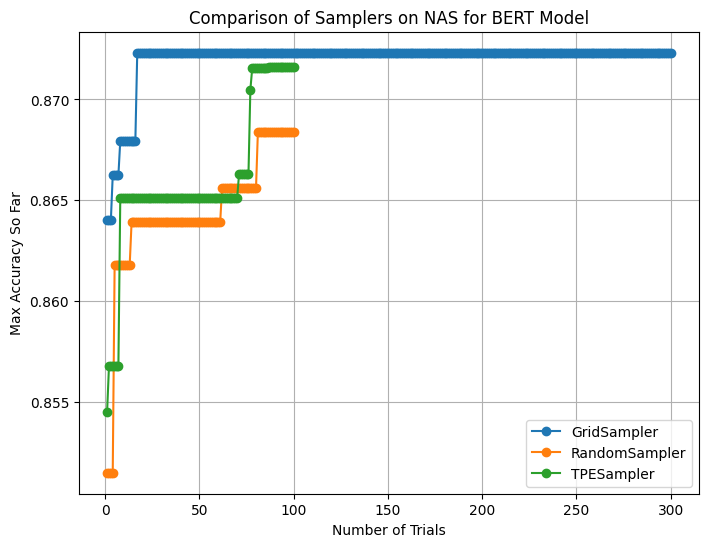

In [15]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.plot(range(1, len(grid_bests)+1), grid_bests, label="GridSampler", marker='o')
# plt.plot(range(1, len(random_bests)+1), random_bests, label="RandomSampler", marker='o')
# plt.plot(range(1, len(tpe_bests)+1), tpe_bests, label="TPESampler", marker='o')
# plt.xlabel("Number of Trials")
# plt.ylabel("Max Accuracy So Far")
# plt.title("Comparison of Samplers on NAS for BERT Model")
# plt.legend()
# plt.grid(True)
# plt.savefig("./tut_5_sampler_NAS.png")
# plt.show()

# Task 2

In [11]:
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

def get_quantized_mg(mg):
    pipe = CompressionPipeline()
    
    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": 8,
                "data_in_frac_width": 4,
                # weight
                "weight_width": 8,
                "weight_frac_width": 4,
                # bias
                "bias_width": 8,
                "bias_frac_width": 4,
            }
        },
    }
    
    pruning_config = {
        "weight": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
        "activation": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
    }
    
    mg, _ = pipe(
        mg,
        pass_args={
            "quantize_transform_pass": quantization_config,
            "prune_transform_pass": pruning_config,
        },
    )

    return mg

In [12]:
def compression_aware_objective(trial):
    # Define the model
    model = construct_model(trial)

    # no compression
    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    trainer.train()
    # eval_results = trainer.evaluate()
    # trial.set_user_attr("acc_wt_compression", eval_results["eval_accuracy"])

    # compression pipeline
    mg = MaseGraph(model.cpu(),
                   hf_input_names=[
                        "input_ids",
                        "attention_mask",
                        "labels",
                    ],
                  )
    mg = get_quantized_mg(mg)
    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=3,
    )

    # compression-aware search (no training)
    eval_results = trainer.evaluate()
    trial.set_user_attr("acc_wt_training", eval_results["eval_accuracy"])

    # compression-aware search (with training)
    trainer.train()
    eval_results = trainer.evaluate()

    # # save finetuned model
    # trial.set_user_attr("model", mg.model)
    
    return eval_results["eval_accuracy"]

In [13]:
def run_cat_study(sampler, n_trials=10, study_name="test_study", is_grid=False):
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=study_name,
    )

    study.optimize(
        compression_aware_objective,
        n_trials=n_trials,  # Increase for more thorough exploration
        timeout=None
    )

    return study

In [28]:
# # GridSampler
# grid_sampler = GridSampler(grid_search_space)
# grid_study = run_study(grid_sampler, n_trials=None, study_name="grid_study_cat", is_grid=True) # n_trials=None => exhaustion

# with open(f"{Path.home()}/tutorial_5_grid_study_cat.pkl", "wb") as f:
#     dill.dump(grid_study, f)

# save_best_accuracy(grid_study, "tutorial_5_grid_study_cat")
# grid_bests = get_best_accuracy_each_trial(grid_study)
# print(grid_bests)

In [ ]:
tpe_cat_sampler = TPESampler()
tpe_cat_study = run_cat_study(tpe_cat_sampler, n_trials=80, study_name="tpe_cat_study")

with open(f"{Path.home()}/tutorial_5_tpe_cat_study.pkl", "wb") as f:
    dill.dump(tpe_cat_study, f)

compression_without_training = get_user_attr_bests(tpe_cat_study, "acc_wt_training")
compression_bests = get_best_accuracy_each_trial(tpe_cat_study)
print(compression_without_training)
print(compression_bests)

with open(f"{Path.home()}/tutorial_5_tpe_cat_best_accuracies.pkl", "wb") as f:
    dill.dump(compression_bests, f)
with open(f"{Path.home()}/tutorial_5_tpe_cat_best_accuracies_no_training.pkl", "wb") as f:
    dill.dump(compression_without_training, f)

In [7]:
import dill
from pathlib import Path

with open(f"{Path.home()}/tutorial_5_tpe_cat_study.pkl", "rb") as f:
    tpe_cat_study = dill.load(f)

with open(f"{Path.home()}/tutorial_5_tpe_best_accuracies.pkl", "rb") as f:
    tpe_bests = dill.load(f)

In [5]:
# with open(f"{Path.home()}/tutorial_5_tpe_best_accuracies.pkl", "wb") as f:
#     obj = get_best_accuracy_each_trial(tpe_bests)
#     dill.dump(obj, f)

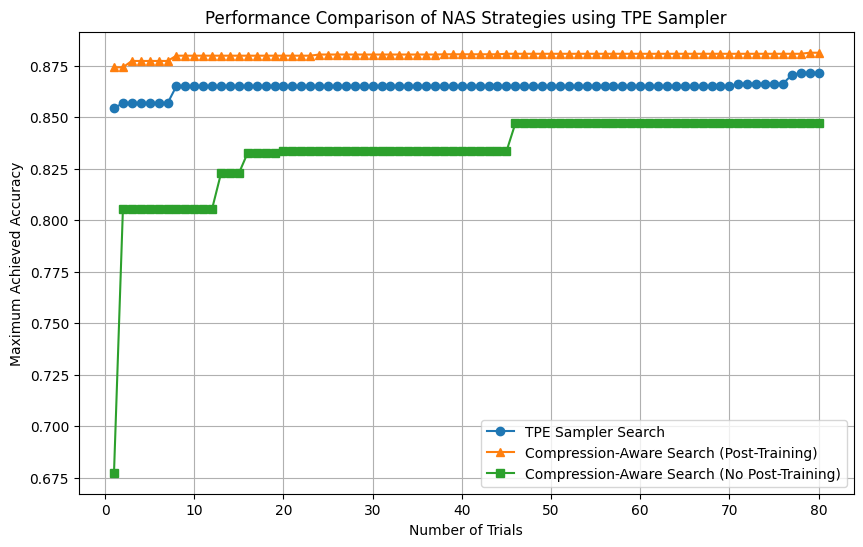

In [13]:
import matplotlib.pyplot as plt

# no_compression = get_user_attr_bests(tpe_cat_study, "acc_wt_compression")
no_compression = tpe_bests[0:80]
compression_without_training = get_user_attr_bests(tpe_cat_study, "acc_wt_training")
compression_bests = get_best_accuracy_each_trial(tpe_cat_study)

trials = list(range(1, len(compression_bests) + 1))

plt.figure(figsize=(10, 6))
plt.plot(trials, no_compression, label="TPE Sampler Search", marker='o')
plt.plot(trials, compression_bests, label="Compression-Aware Search (Post-Training)", marker='^')
plt.plot(trials, compression_without_training, label="Compression-Aware Search (No Post-Training)", marker='s')
plt.xlabel("Number of Trials")
plt.ylabel("Maximum Achieved Accuracy")
plt.title("Performance Comparison of NAS Strategies using TPE Sampler")
plt.legend()
plt.grid(True)
plt.savefig("./imgs/tut5_CA_NAS.png")
plt.show()